In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import sys
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Get parent directory
parent_dir = os.path.abspath("..")

# Add to sys.path
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [3]:
from src.preprocess import load_data, preprocess_data, split_data
from src.features import get_feature_groups

In [4]:
# Read data
df = load_data()
train_df, test_df = split_data(df)
# Show first n rows of data
train_df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1427,0,53,3.0,1,20.0,0.0,0,0,0,221.0,131.0,89.0,24.09,90.0,95.0,0
3257,0,64,4.0,1,6.0,0.0,0,1,0,239.0,143.0,84.0,20.06,55.0,73.0,0
3822,0,38,3.0,0,0.0,0.0,0,0,0,185.0,100.0,72.0,22.15,85.0,83.0,0
1263,0,49,1.0,0,0.0,0.0,0,0,0,270.0,126.5,67.5,26.56,70.0,77.0,0
3575,1,56,2.0,1,20.0,0.0,0,0,0,186.0,116.0,67.0,24.62,70.0,83.0,0


In [5]:
TARGET = "TenYearCHD"

In [6]:
train_X = train_df.drop(TARGET, axis=1)
train_y = train_df[TARGET]
test_X = test_df.drop(TARGET, axis=1)
test_y = test_df[TARGET]

In [7]:
binary_features, categorical_features, numeric_features = get_feature_groups(train_X)
print(binary_features)
print(categorical_features)
print(numeric_features)

['diabetes', 'male', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'currentSmoker']
['education']
['glucose', 'sysBP', 'totChol', 'heartRate', 'age', 'cigsPerDay', 'BMI', 'diaBP']


In [8]:
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("bin", binary_pipeline, binary_features),
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("logistic_regression", LogisticRegression(random_state=42, max_iter=1000))
])

In [9]:
fitted_model = pipe.fit(train_X, train_y)

c:\Users\bogus\Desktop\Projects\Heart-Disease\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
fitted_model["logistic_regression"].coef_

array([[ 5.02364422e-01,  2.93032084e-01,  1.18817660e-01,
         1.16956742e+00,  2.53048115e-01, -5.23108160e-02,
         3.88932471e-03,  1.29514900e-02,  1.19014765e-04,
        -6.75596775e-03,  6.39240324e-02,  2.73387504e-02,
        -8.92688917e-03,  2.41495136e-03, -1.17706853e+00,
        -9.59725842e-01, -1.03714608e+00, -1.04890164e+00,
        -8.58015699e-01]])

In [11]:
fitted_model.score(train_X, train_y)

0.8561320754716981

In [12]:
y_pred = fitted_model.predict(train_X)
print (classification_report(train_y, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2871
           1       0.75      0.10      0.17       521

    accuracy                           0.86      3392
   macro avg       0.80      0.55      0.55      3392
weighted avg       0.84      0.86      0.81      3392



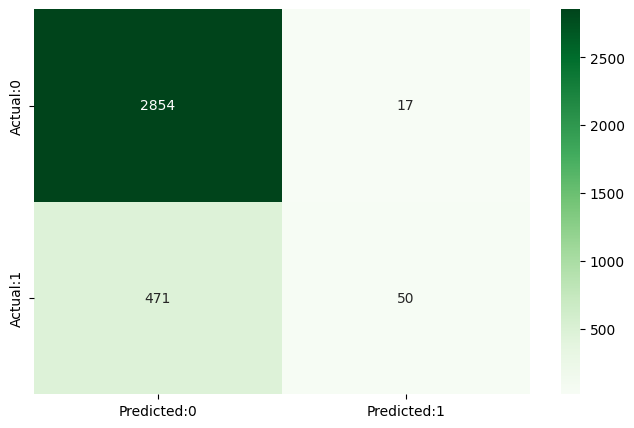

In [13]:
cm = confusion_matrix(train_y, y_pred)
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")

plt.show()